# Component: East Antarctic Ice Sheet (EAIS)

This notebook calibrates, validates, and projects the EAIS component of GMSL rise.

**Key features:**
- IMBIE observations (1992–2020) show near-zero net mass change with no detectable
  temperature sensitivity (BIC weakly favors quadratic, but the signal is
  too noisy to trust; projections use literature SMB sensitivities instead).
- EAIS mass balance is dominated by precipitation: warming increases snowfall via
  Clausius–Clapeyron, partially offset by marginal dynamic losses.
- **Projection approach:** RCM-derived SMB sensitivity (`EAIS_SMB` from
  `smb_projections.py`), not the DOLS fit. Same rationale as Greenland: the IMBIE
  record is too short and noisy for a data-driven T regression to capture the
  accumulation response. Literature values (Frieler et al. 2015; Ligtenberg et al.
  2013) constrain C_T ≈ +60 ± 20 Gt/yr/°C GMST (positive = mass gain = negative SLR).
- DOLS fit retained as a diagnostic confirming consistency with near-zero contribution.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
sys.path.insert(0, str(Path('.').resolve() / 'arete_mpl'))
import arete_mpl
arete_mpl.use('poster')

sys.path.insert(0, '.')
from slr_data_readers import read_imbie_west_antarctica, read_berkeley_earth
from bayesian_models import (
    build_level_design_vectors, fit_bayesian_level,
    calibrate_exponential_prior, check_convergence,
)
from slr_projections import project_component_level_ensemble
from component_analysis import apply_sigma_taper, compute_component_rates
from component_projections import read_ipcc_component_nc, ipcc_extract
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_projection_twopanel,
    plot_component_histogram,
    plot_component_ridge,
)
from smb_projections import EAIS_SMB, project_smb_ensemble
from slr_forecast.config import BASELINE_YEAR

H5_PATH = '../data/processed/slr_processed_data.h5'
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

N_SAMPLES = 2000

## 1. Data Loading

In [2]:
# ── IMBIE East Antarctica (satellite-era mass balance, 1992–2020) ──
# Use read_imbie_west_antarctica for all IMBIE mm-format files — same column
# layout. Reader converts mm → m and fixes negative-sigma quirk.
df_eais = read_imbie_west_antarctica(
    f'{RAW_DIR}/ice_sheets/antarctica/imbie_east_antarctica_2021_mm.csv')

# Annualize (reader output is already in meters — no further conversion)
t = df_eais['decimal_year'].values
year_int = np.floor(t).astype(int)
unique_years = np.unique(year_int)
eais_year = unique_years.astype(float) + 0.5
eais_H = np.array([df_eais['cumulative_mass_balance'].values[year_int == yr][-1]
                    for yr in unique_years])
eais_sigma = np.array([np.abs(df_eais['cumulative_mass_balance_sigma'].values[year_int == yr][-1])
                        for yr in unique_years])
bl_idx = np.argmin(np.abs(eais_year - BASELINE_YEAR))
eais_rebase = eais_H - eais_H[bl_idx]

# ── Berkeley Earth monthly GMST (for DOLS diagnostic and SSP projections) ──
df_temp = pd.read_hdf(H5_PATH, key='harmonized/df_berkeley_h')
temp_monthly = df_temp['temperature'].values
temp_time_monthly = (df_temp.index.year
                     + (df_temp.index.month - 0.5) / 12.0).values

print(f'EAIS IMBIE: {eais_year[0]:.0f}–{eais_year[-1]:.0f}, {len(eais_year)} points')
print(f'EAIS cumulative at end: {eais_rebase[-1]*M_TO_MM:.1f} mm')

# ── SMB sensitivity from literature ──
# EAIS mass balance is dominated by accumulation (Clausius–Clapeyron: ~5%/°C
# of ~1200 Gt/yr). C_T > 0 means warming → mass gain → negative SLR.
print(f'\nEAIS SMB sensitivity (from smb_projections.py):')
print(f'  C_T  = {EAIS_SMB.C_T:.0f} ± {EAIS_SMB.C_T_sigma:.0f} Gt/yr/°C GMST')
print(f'  Reference: {EAIS_SMB.reference}')
print(f'  In mm SLE/yr/°C: {EAIS_SMB.C_T * 1.0/362500.0 * M_TO_MM:.3f} (negative = SL fall)')

EAIS IMBIE: 1992–2020, 29 points
EAIS cumulative at end: -0.4 mm

EAIS SMB sensitivity (from smb_projections.py):
  C_T  = 60 ± 20 Gt/yr/°C GMST
  Reference: Frieler et al. (2015); Ligtenberg et al. (2013)
  In mm SLE/yr/°C: 0.166 (negative = SL fall)


In [3]:
# ══════════════════════════════════════════════════════════════════
# REFIT SWITCH — set False to skip fitting and load saved results.
# If loading fails (no HDF5 file), fitting runs automatically.
# ══════════════════════════════════════════════════════════════════
REFIT = True

from component_io import save_eais, load_component

if not REFIT:
    try:
        _loaded = load_component('eais')
        eais_proj = _loaded['projections']
        PROJ_YEARS = _loaded['proj_years']
        print(f'Loaded eais from HDF5: {list(eais_proj.keys())}')
    except (FileNotFoundError, KeyError) as e:
        print(f'Load failed ({e}) — falling back to REFIT=True')
        REFIT = True

## 2. DOLS Diagnostic Fit

DOLS rate–temperature fit on IMBIE data. This is a **diagnostic**, not the
projection model. BIC weakly favors the quadratic (ΔBIC = +4.1), but
the signal is dominated by noise (R² = 0.56 linear, 0.66 quadratic) and
the IMBIE record is too short to reliably distinguish trend from
temperature response. The projection uses literature-derived SMB sensitivities
instead (§4).


In [4]:
if REFIT:
    # ── Build design vectors ──
    design_eais = build_level_design_vectors(
        temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
        obs_times=eais_year)

    # ── Priors ──
    PRIOR_SCALE_A = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.10/M_TO_MM)
    PRIOR_SCALE_B = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.20/M_TO_MM)
    prior_kw = dict(prior_scale_a=PRIOR_SCALE_A, prior_scale_b=PRIOR_SCALE_B,
                    prior_c_mean=0.0003, prior_c_sigma=0.001,
                    prior_sigma_extra_scale=0.005, prior_H0_sigma=0.005)

    # ── Quadratic fit ──
    result_quad = fit_bayesian_level(
        H_obs=eais_rebase, sigma_obs=eais_sigma,
        I2_obs=design_eais['I2_obs'], I1_obs=design_eais['I1_obs'],
        I0_obs=design_eais['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=200, **prior_kw)

    # ── Linear fit ──
    result_lin = fit_bayesian_level(
        H_obs=eais_rebase, sigma_obs=eais_sigma,
        I2_obs=np.zeros_like(design_eais['I2_obs']),
        I1_obs=design_eais['I1_obs'], I0_obs=design_eais['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=300, **prior_kw)

    # ── BIC ──
    n = len(eais_year)
    rss_q = np.sum(result_quad.residuals**2)
    rss_l = np.sum(result_lin.residuals**2)
    bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
    bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
    delta_bic = bic_l - bic_q

    a_med = np.median(result_quad.posterior_samples[:, 0]) * M_TO_MM
    b_med = np.median(result_lin.posterior_samples[:, 1]) * M_TO_MM
    c_med = np.median(result_lin.posterior_samples[:, 2]) * M_TO_MM

    print(f'Linear:    b = {b_med:.4f} mm/yr/°C, c = {c_med:.4f} mm/yr, R² = {result_lin.r2:.4f}')
    print(f'Quadratic: a = {a_med:.4f} mm/yr/°C², R² = {result_quad.r2:.4f}')
    print(f'ΔBIC = {delta_bic:+.1f} ({"quadratic" if delta_bic > 2 else "linear"} preferred)')
    print(f'P(a>0) = {np.mean(result_quad.posterior_samples[:, 0] > 0)*100:.0f}%')
else:
    print('REFIT=False — skipping DOLS diagnostic fit (will load from HDF5 after projections)')

Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.754, b=-0.105, c=-0.053 mm/yr, σ_extra=0.10 mm


  0%|          | 0/6000 [00:00<?, ?it/s]

  1%|▏         | 77/6000 [00:00<00:07, 765.09it/s]

  3%|▎         | 154/6000 [00:00<00:07, 751.83it/s]

  4%|▍         | 233/6000 [00:00<00:07, 767.45it/s]

...

 97%|█████████▋| 5813/6000 [00:06<00:00, 875.06it/s]

 98%|█████████▊| 5901/6000 [00:06<00:00, 858.96it/s]

100%|█████████▉| 5987/6000 [00:07<00:00, 848.75it/s]

100%|██████████| 6000/6000 [00:07<00:00, 852.73it/s]

  Convergence diagnostics:
    dalpha_dT: R-hat=1.007  ESS_bulk=260  ESS_tail=384
    alpha0: R-hat=1.028  ESS_bulk=105  ESS_tail=395
    trend: R-hat=1.009  ESS_bulk=199  ESS_tail=477
    log_sigma_extra: R-hat=1.015  ESS_bulk=239  ESS_tail=267
    H0: R-hat=1.014  ESS_bulk=136  ESS_tail=398
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.043, b=0.024, c=-0.018 mm/yr
  σ_extra: median=0.09 mm [0.00, 0.31]
  R² = 0.5927,  acceptance = 0.47
Linear:    b = 0.0188 mm/yr/°C, c = -0.0185 mm/yr, R² = 0.5927
Quadratic: a = 0.0422 mm/yr/°C², R² = 0.6918
ΔBIC = +4.7 (quadratic preferred)
P(a>0) = 100%


## 3. Diagnostics & Validation

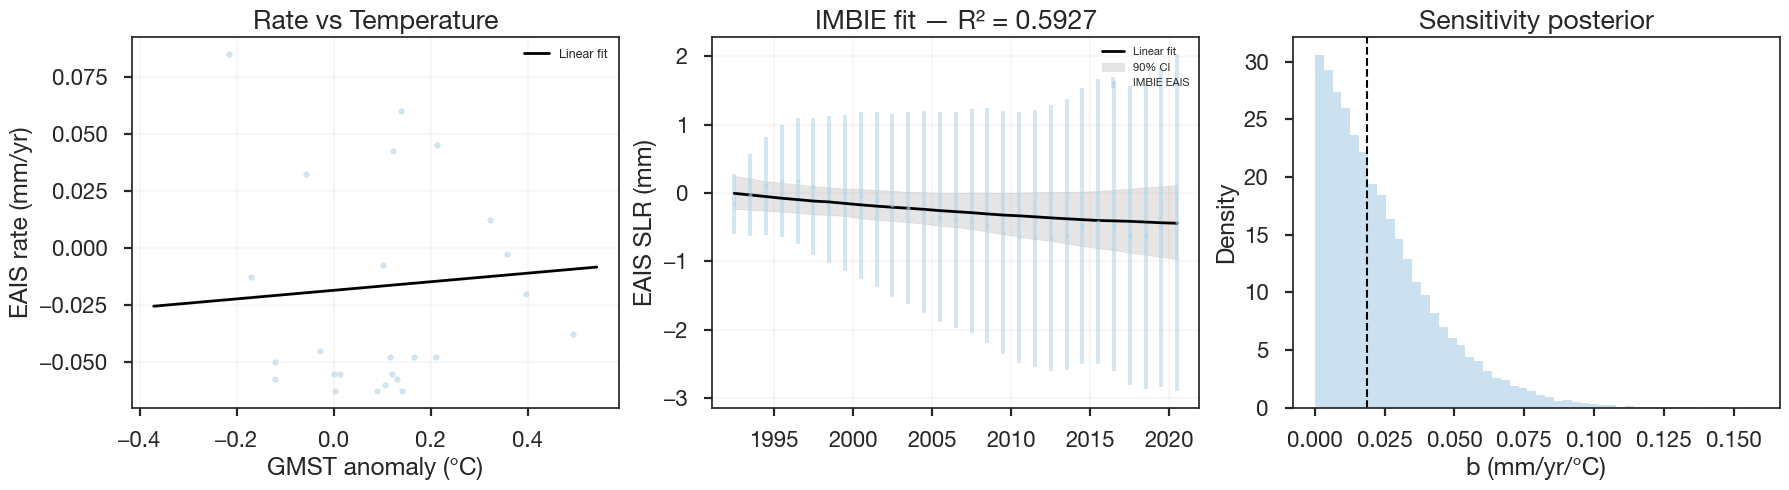

In [5]:
if REFIT:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel A: Rate vs T
    ax = axes[0]
    rates = compute_component_rates(eais_year, eais_rebase, window=2) * M_TO_MM
    yr_int = np.floor(temp_time_monthly).astype(int)
    T_ann = np.array([temp_monthly[yr_int == y].mean() for y in np.unique(yr_int)])
    T_ann_years = np.unique(yr_int) + 0.5
    T_at_eais = np.interp(eais_year, T_ann_years, T_ann)
    valid = np.isfinite(rates)
    ax.scatter(T_at_eais[valid], rates[valid], s=15, alpha=0.6, color=COMP_COLORS['EAIS'])
    T_grid = np.linspace(T_at_eais.min()-0.05, T_at_eais.max()+0.05, 100)
    ax.plot(T_grid, b_med * T_grid + c_med, 'k-', lw=2, label='Linear fit')
    ax.set_xlabel('GMST anomaly (°C)')
    ax.set_ylabel('EAIS rate (mm/yr)')
    ax.set_title('Rate vs Temperature')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

    # Panel B: IMBIE fit
    ax = axes[1]
    from component_analysis import model_ensemble_draws
    H_ens = model_ensemble_draws(result_lin, np.zeros_like(design_eais['I2_obs']),
                                  design_eais['I1_obs'], design_eais['I0_obs'])
    p5, p50, p95 = np.percentile(H_ens * M_TO_MM, [5, 50, 95], axis=0)
    ax.errorbar(eais_year, eais_rebase * M_TO_MM, yerr=2*eais_sigma*M_TO_MM,
                fmt='o', ms=3, color=COMP_COLORS['EAIS'], alpha=0.6, label='IMBIE EAIS')
    ax.plot(eais_year, p50, 'k-', lw=2, label='Linear fit')
    ax.fill_between(eais_year, p5, p95, color='gray', alpha=0.2, label='90% CI')
    ax.set_ylabel('EAIS SLR (mm)')
    ax.set_title(f'IMBIE fit — R² = {result_lin.r2:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    # Panel C: Posteriors
    ax = axes[2]
    ax.hist(result_lin.posterior_samples[:, 1]*M_TO_MM, bins=50, density=True,
            alpha=0.7, color=COMP_COLORS['EAIS'])
    ax.axvline(b_med, color='k', ls='--', lw=1.5)
    ax.set_xlabel('b (mm/yr/°C)')
    ax.set_ylabel('Density')
    ax.set_title('Sensitivity posterior')

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/component_eais_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('REFIT=False — skipping fit diagnostics')

## 4. Projections

**SMB-based projections** using literature-derived C_T (Frieler et al. 2015;
Ligtenberg et al. 2013). Same approach as Greenland: the IMBIE record is too
short and noisy for a data-driven T sensitivity, so we use RCM constraints.

C_T = +60 ± 20 Gt/yr/°C GMST (positive = mass gain from increased snowfall).
This produces a **negative SLR contribution** under warming — EAIS partially
offsets other components.

In [6]:
# Constants needed by downstream cells regardless of REFIT
SSP_H5_MAP = {'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
              'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5'}
PROJ_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
            'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}
if REFIT:
    PROJ_YEARS = np.arange(1950, 2151, dtype=float)

# Load SSP temperatures (needed for plots downstream)
df_hist = pd.read_hdf(H5_PATH, key='projections/temp/Historical')
overlap_mask = (df_hist['decimal_year'] >= 1995) & (df_hist['decimal_year'] <= 2005)
hist_bl = df_hist.loc[overlap_mask, 'temperature'].mean()
temp_bl = np.mean(temp_monthly[(temp_time_monthly >= 1995) & (temp_time_monthly <= 2005)])
offset = hist_bl - temp_bl

if REFIT:
    # ── Load and rebaseline SSP temperature scenarios ──
    temp_projections = {}
    for ssp_name, h5_key in SSP_H5_MAP.items():
        df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
        hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
        combined = pd.concat([hist_part, df_ssp]).sort_index()
        combined = combined[~combined.index.duplicated(keep='last')]
        combined['temperature'] = combined['temperature'] - offset
        temp_projections[ssp_name] = combined

    # ── SMB projections: ΔḢ_smb = C_T · ΔT ──
    # C_T > 0 for EAIS (mass gain from snowfall), so projections are negative SLR.
    print('Projecting EAIS SMB (literature C_T)...')
    T_proj_annual = {}
    for ssp in PROJ_SSPS:
        df_t = temp_projections[ssp]
        T_proj_annual[ssp] = np.interp(PROJ_YEARS, df_t['decimal_year'].values,
                                        df_t['temperature'].values)

    eais_proj = project_smb_ensemble(
        sensitivity=EAIS_SMB,
        T_proj=T_proj_annual,
        time_proj=PROJ_YEARS,
        T_baseline=0.0,
        n_samples=N_SAMPLES,
        seed=650,
    )

    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    for ssp in PROJ_SSPS:
        med = eais_proj[ssp]['median'][idx_2100] * M_TO_MM
        lo = eais_proj[ssp]['p5'][idx_2100] * M_TO_MM
        hi = eais_proj[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  {ssp} EAIS at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

    # ── Save to HDF5 ──
    save_eais(
        result_lin=result_lin,
        obs_years=eais_year,
        obs_H=eais_rebase,
        obs_sigma=eais_sigma,
        proj_dict=eais_proj,
        extra_metadata={'r2': float(result_lin.r2),
                        'projection_method': 'smb_literature',
                        'C_T': float(EAIS_SMB.C_T),
                        'C_T_sigma': float(EAIS_SMB.C_T_sigma)},
    )
else:
    # Already loaded in REFIT switch cell — just print summary
    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    for ssp in PROJ_SSPS:
        if ssp in eais_proj:
            med = eais_proj[ssp]['median'][idx_2100] * M_TO_MM
            lo = eais_proj[ssp]['p5'][idx_2100] * M_TO_MM
            hi = eais_proj[ssp]['p95'][idx_2100] * M_TO_MM
            print(f'  {ssp}: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

Projecting EAIS SMB (literature C_T)...
  SSP1-2.6 EAIS at 2100: -13 [-20, -6] mm
  SSP2-4.5 EAIS at 2100: -19 [-29, -9] mm
  SSP3-7.0 EAIS at 2100: -24 [-37, -12] mm
  SSP5-8.5 EAIS at 2100: -30 [-45, -14] mm


Saved eais → /Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/data/processed/component_results.h5  (461068 KB total)


ISMIP6 EAIS: 77 model-experiment runs


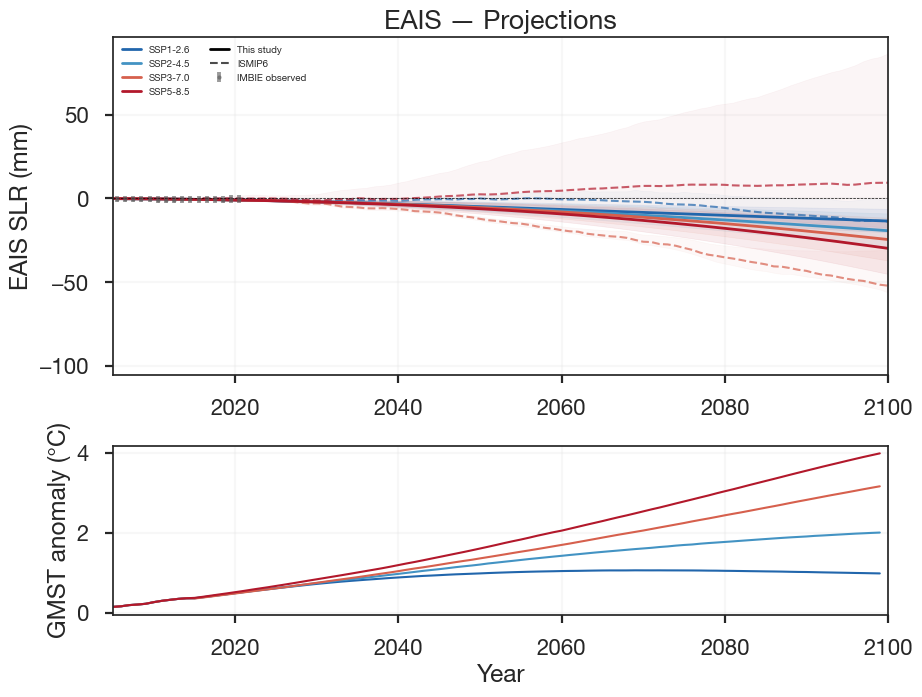

In [7]:
# ── Load ISMIP6 EAIS data for overlay on projection plot ──
from component_projections import read_ismip6_regional, ismip6_ensemble_stats

ISMIP6_BASE = f'{RAW_DIR}/ice_sheets/ismip6/ComputedScalarsPaper'
eais_ismip6 = read_ismip6_regional(ISMIP6_BASE, region=2)
print(f'ISMIP6 EAIS: {len(eais_ismip6)} model-experiment runs')

SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
            'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}
EXP_GROUPS = {
    'SSP5-8.5': ['exp13'], 'SSP3-7.0': ['exp12'],
    'SSP1-2.6': ['exp10'], 'CMIP6 median': ['exp05', 'exp06'],
}

# Build temperature scenarios for lower panel
temp_scenarios = {}
for ssp_name, h5_key in SSP_H5_MAP.items():
    df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
    hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
    combined = pd.concat([hist_part, df_ssp]).sort_index()
    combined = combined[~combined.index.duplicated(keep='last')]
    combined['temperature'] = combined['temperature'] - offset
    ann = combined.groupby(combined['decimal_year'].round(0)).agg(
        temperature=('temperature', 'mean')).reset_index()
    temp_scenarios[ssp_name] = {'years': ann['decimal_year'].values,
                                 'temperature': ann['temperature'].values}

# ── Two-panel projection plot with ISMIP6 overlay ──
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 7.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.28)
ax_sl = fig.add_subplot(gs[0])
ax_t = fig.add_subplot(gs[1])

proj_mask = (PROJ_YEARS >= 2005) & (PROJ_YEARS <= 2150)
yr_plot = PROJ_YEARS[proj_mask]

for ssp in PROJ_SSPS:
    color = SSP_COLORS.get(ssp, 'gray')
    p = eais_proj[ssp]
    med = p['median'][proj_mask] * M_TO_MM
    lo = p['p5'][proj_mask] * M_TO_MM
    hi = p['p95'][proj_mask] * M_TO_MM
    ax_sl.plot(yr_plot, med, color=color, lw=2, label=f'{ssp}')
    ax_sl.fill_between(yr_plot, lo, hi, color=color, alpha=0.08)

    # ISMIP6 ensemble overlay (dashed)
    exps = EXP_GROUPS.get(ssp)
    if exps:
        stats = ismip6_ensemble_stats(eais_ismip6, experiments=exps,
                                       baseline_year=BASELINE_YEAR)
        if stats is not None:
            ax_sl.plot(stats['time'], stats['median'] * M_TO_MM,
                       color=color, ls='--', lw=1.5, alpha=0.7)
            ax_sl.fill_between(stats['time'],
                               stats['p5'] * M_TO_MM, stats['p95'] * M_TO_MM,
                               color=color, alpha=0.04)

# Observations
ax_sl.errorbar(eais_year, eais_rebase * M_TO_MM, yerr=2 * eais_sigma * M_TO_MM,
               fmt='o', ms=3, color='0.35', alpha=0.6, label='IMBIE observed')
ax_sl.plot([], [], 'k-', lw=2, label='This study')
ax_sl.plot([], [], 'k--', lw=1.5, alpha=0.7, label='ISMIP6')
ax_sl.set_ylabel('EAIS SLR (mm)')
ax_sl.set_title('EAIS — Projections')
ax_sl.legend(fontsize=7, loc='upper left', ncol=2)
ax_sl.axhline(0, color='k', lw=0.5, ls='--')
ax_sl.set_xlim(2005, 2100)
ax_sl.grid(True, alpha=0.2)

# Temperature panel
for ssp in PROJ_SSPS:
    color = SSP_COLORS.get(ssp, 'gray')
    ts = temp_scenarios[ssp]
    mask_t = (ts['years'] >= 2005) & (ts['years'] <= 2150)
    ax_t.plot(ts['years'][mask_t], ts['temperature'][mask_t], color=color, lw=1.5)
ax_t.set_ylabel('GMST anomaly (°C)')
ax_t.set_xlabel('Year')
ax_t.set_xlim(2005, 2100)
ax_t.grid(True, alpha=0.2)

plt.savefig(f'{FIG_DIR}/component_eais_twopanel.png', dpi=150, bbox_inches='tight')
plt.show()

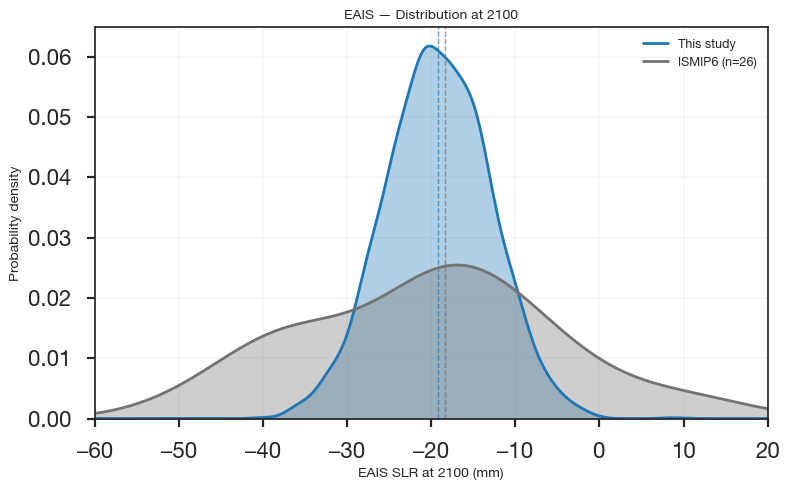

In [8]:
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
HIST_SSP = 'SSP2-4.5'

our_samples = eais_proj[HIST_SSP]['samples'][:, idx_2100] * M_TO_MM

# ISMIP6 EAIS samples at 2100 (from individual model runs)
ismip6_exps = EXP_GROUPS.get(HIST_SSP, ['exp05', 'exp06'])
ismip6_vals_2100 = []
for key, val in eais_ismip6.items():
    if key[2] not in ismip6_exps:
        continue
    bl_idx = np.argmin(np.abs(val['time'] - BASELINE_YEAR))
    idx_end = np.argmin(np.abs(val['time'] - 2100))
    ismip6_vals_2100.append((val['sle_m'][idx_end] - val['sle_m'][bl_idx]) * M_TO_MM)

sample_sets = [our_samples]
labels = ['This study']
colors = ['tab:blue']
if len(ismip6_vals_2100) > 0:
    sample_sets.append(np.array(ismip6_vals_2100))
    labels.append(f'ISMIP6 (n={len(ismip6_vals_2100)})')
    colors.append('0.45')

plot_component_histogram(sample_sets, labels, colors, 'EAIS', year=2100,xlim=(-60,20),
                          save_path=f'{FIG_DIR}/component_eais_histogram_2100.png')

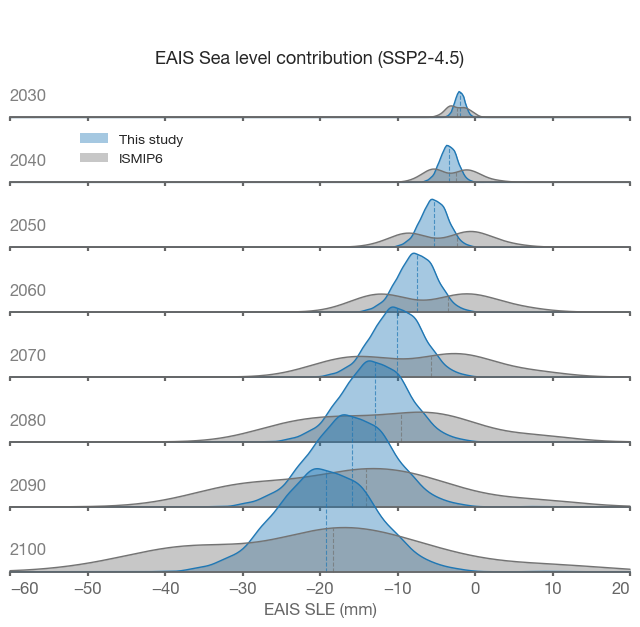

In [9]:
# ── Ridge plot EAIS: distribution evolution at decadal intervals ──
RIDGE_YEARS = list(range(2030, 2110, 10))
RIDGE_SSP = 'SSP2-4.5'
ismip6_exps_ridge = EXP_GROUPS.get(RIDGE_SSP, ['exp05', 'exp06'])

samples_by_year = {}
for yr in RIDGE_YEARS:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    year_dict = {'This study': eais_proj[RIDGE_SSP]['samples'][:, idx_yr]}

    # ISMIP6 values at this year
    ismip6_vals = []
    for key, val in eais_ismip6.items():
        if key[2] not in ismip6_exps_ridge:
            continue
        bl_idx = np.argmin(np.abs(val['time'] - BASELINE_YEAR))
        yr_idx = np.argmin(np.abs(val['time'] - yr))
        if np.abs(val['time'][yr_idx] - yr) < 5:
            ismip6_vals.append(val['sle_m'][yr_idx] - val['sle_m'][bl_idx])
    if len(ismip6_vals) > 0:
        year_dict['ISMIP6'] = np.array(ismip6_vals)

    samples_by_year[yr] = year_dict

plot_component_ridge(samples_by_year, 'EAIS', RIDGE_SSP,
                      source_colors={'This study': 'tab:blue', 'ISMIP6': '0.45'},
                      xlabel='EAIS SLE (mm)',
                      units='mm',
                      xlim=(-60,20),
                      legend_bbox=(0.3, -0.03),
                      top=1.05,
                      fontsize={'year': 12, 'title': 13, 'legend': 10, 'xlabel': 12, 'xtick': 12},
                      title=f'EAIS Sea level contribution ({RIDGE_SSP})',
                      save_path=f'{FIG_DIR}/component_eais_ridge.png')

## 5. IPCC Comparison

EAIS is part of the total AIS component in IPCC AR6. Direct comparison requires
extracting the EAIS fraction, which is not straightforward from the aggregated NetCDFs.
We note that EAIS is expected to contribute near-zero or slightly negative SLR
(mass gain from increased snowfall), consistent with our SMB literature-based projections.

ISMIP6 EAIS: 77 total model-experiment runs


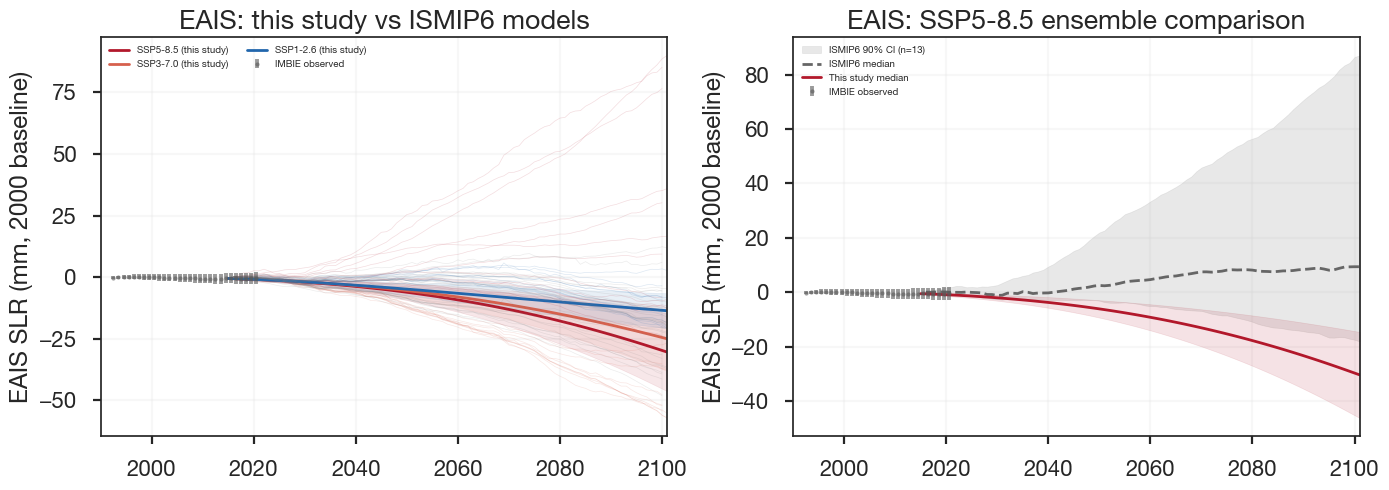


EAIS at 2100 (mm, relative to 2000):
SSP                        This study                ISMIP6    n
SSP5-8.5               -30 [-45, -14]         +9 [-18, +87]   13
SSP3-7.0               -24 [-37, -12]        -52 [-57, -31]   10
SSP1-2.6                -13 [-20, -6]         -14 [-21, -1]   12
CMIP6 median                                  -20 [-41, +3]   26


In [10]:
# ── ISMIP6 EAIS comparison (ivaf_region_2) ──
from component_projections import read_ismip6_regional, ismip6_ensemble_stats

ISMIP6_BASE = f'{RAW_DIR}/ice_sheets/ismip6/ComputedScalarsPaper'

# Read all SSP-mapped experiments for EAIS
eais_ismip6 = read_ismip6_regional(ISMIP6_BASE, region=2)
print(f'ISMIP6 EAIS: {len(eais_ismip6)} total model-experiment runs')

# Group by SSP-relevant experiments
EXP_GROUPS = {
    'SSP5-8.5': ['exp13'],
    'SSP3-7.0': ['exp12'],
    'SSP1-2.6': ['exp10'],
    'CMIP6 median': ['exp05', 'exp06'],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: ISMIP6 spaghetti + our projections
ax = axes[0]
proj_mask = (PROJ_YEARS >= 2015) & (PROJ_YEARS <= 2101)
yr_plot = PROJ_YEARS[proj_mask]

# Plot ISMIP6 individual runs (thin, colored by SSP) and our median (thick, colored)
for ssp_label, exps in EXP_GROUPS.items():
    color = SSP_COLORS.get(ssp_label, 'gray')
    # ISMIP6 individual trajectories
    for key, val in eais_ismip6.items():
        if key[2] not in exps:
            continue
        t = val['time']
        sle = val['sle_m']
        bl_idx = np.argmin(np.abs(t - BASELINE_YEAR))
        sle_rb = sle - sle[bl_idx]
        ax.plot(t, sle_rb * M_TO_MM, color=color, alpha=0.15, lw=0.5)

    # Our projection
    if ssp_label in eais_proj:
        p = eais_proj[ssp_label]
        ax.plot(yr_plot, p['median'][proj_mask] * M_TO_MM, color=color, lw=2,
                label=f'{ssp_label} (this study)')
        ax.fill_between(yr_plot, p['p5'][proj_mask] * M_TO_MM,
                        p['p95'][proj_mask] * M_TO_MM, color=color, alpha=0.1)

# Observations
ax.errorbar(eais_year, eais_rebase * M_TO_MM, yerr=2 * eais_sigma * M_TO_MM,
            fmt='o', ms=3, color='0.35', alpha=0.6, label='IMBIE observed')
ax.set_xlim(1990, 2101)
ax.set_ylabel('EAIS SLR (mm, 2000 baseline)')
ax.set_title('EAIS: this study vs ISMIP6 models')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.2)

# Panel B: Ensemble statistics for SSP5-8.5
ax = axes[1]
ssp_plot = 'SSP5-8.5'
exps_plot = EXP_GROUPS[ssp_plot]
stats = ismip6_ensemble_stats(eais_ismip6, experiments=exps_plot,
                               baseline_year=BASELINE_YEAR)
if stats is not None:
    color = SSP_COLORS.get(ssp_plot, 'C3')
    ax.fill_between(stats['time'], stats['p5'] * M_TO_MM, stats['p95'] * M_TO_MM,
                    color='0.7', alpha=0.3, label=f'ISMIP6 90% CI (n={stats["n_models"]})')
    ax.plot(stats['time'], stats['median'] * M_TO_MM, color='0.4', lw=2, ls='--',
            label='ISMIP6 median')

if ssp_plot in eais_proj:
    p = eais_proj[ssp_plot]
    ax.plot(yr_plot, p['median'][proj_mask] * M_TO_MM, color=color, lw=2,
            label='This study median')
    ax.fill_between(yr_plot, p['p5'][proj_mask] * M_TO_MM,
                    p['p95'][proj_mask] * M_TO_MM, color=color, alpha=0.12)

ax.errorbar(eais_year, eais_rebase * M_TO_MM, yerr=2 * eais_sigma * M_TO_MM,
            fmt='o', ms=3, color='0.35', alpha=0.6, label='IMBIE observed')
ax.set_xlim(1990, 2101)
ax.set_ylabel('EAIS SLR (mm, 2000 baseline)')
ax.set_title(f'EAIS: {ssp_plot} ensemble comparison')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_eais_ismip6.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f'\nEAIS at 2100 (mm, relative to {BASELINE_YEAR:.0f}):')
print(f'{"SSP":<16s} {"This study":>20s}  {"ISMIP6":>20s}  {"n":>3s}')
for ssp_label, exps in EXP_GROUPS.items():
    stats_s = ismip6_ensemble_stats(eais_ismip6, experiments=exps,
                                     baseline_year=BASELINE_YEAR)
    our = ''
    if ssp_label in eais_proj:
        idx = np.argmin(np.abs(PROJ_YEARS - 2100))
        p = eais_proj[ssp_label]
        our = f'{p["median"][idx]*M_TO_MM:+.0f} [{p["p5"][idx]*M_TO_MM:+.0f}, {p["p95"][idx]*M_TO_MM:+.0f}]'
    ism = ''
    n = 0
    if stats_s is not None:
        ism = f'{stats_s["median"][-1]*M_TO_MM:+.0f} [{stats_s["p5"][-1]*M_TO_MM:+.0f}, {stats_s["p95"][-1]*M_TO_MM:+.0f}]'
        n = stats_s['n_models']
    print(f'{ssp_label:<16s} {our:>20s}  {ism:>20s}  {n:>3d}')

## 6. Appendix: Sensitivity 

### Justification for SMB literature-based projections
EAIS observations show near-zero net mass change with no clear temperature dependence.
The BIC comparison weakly favors the quadratic over linear (ΔBIC = +4.1), but
the fitted sensitivities are small and dominated by noise, so the DOLS fit is
retained only as a diagnostic. Projections use literature-derived SMB sensitivities
(§4). This is physically consistent: EAIS is gaining mass from increased precipitation
while marine-based sectors show limited dynamical change over the observational period.

In [11]:
F_MAX_VALUES = [1, 2, 3]

print(f'{"f_max":>5} {"a (mm/yr/°C²)":>16} {"b (mm/yr/°C)":>16} {"R²_lin":>8} {"R²_quad":>8} {"ΔBIC":>8}')
print('-' * 75)

for f_max in F_MAX_VALUES:
    sig_tapered = apply_sigma_taper(eais_sigma, eais_year, 2005, f_max)
    res_q = fit_bayesian_level(
        H_obs=eais_rebase, sigma_obs=sig_tapered,
        I2_obs=design_eais['I2_obs'], I1_obs=design_eais['I1_obs'],
        I0_obs=design_eais['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=200+f_max*100, **prior_kw)
    res_l = fit_bayesian_level(
        H_obs=eais_rebase, sigma_obs=sig_tapered,
        I2_obs=np.zeros_like(design_eais['I2_obs']),
        I1_obs=design_eais['I1_obs'], I0_obs=design_eais['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=300+f_max*100, **prior_kw)

    a_s = np.median(res_q.posterior_samples[:, 0]) * M_TO_MM
    b_s = np.median(res_l.posterior_samples[:, 1]) * M_TO_MM
    rss_q = np.sum(res_q.residuals**2)
    rss_l = np.sum(res_l.residuals**2)
    bic_q = n * np.log(rss_q/n) + 5*np.log(n)
    bic_l = n * np.log(rss_l/n) + 4*np.log(n)
    print(f'{f_max:>5} {a_s:>16.4f} {b_s:>16.4f} {res_l.r2:>8.4f} {res_q.r2:>8.4f} {bic_l-bic_q:>+8.1f}')

f_max    a (mm/yr/°C²)     b (mm/yr/°C)   R²_lin  R²_quad     ΔBIC
---------------------------------------------------------------------------
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.754, b=-0.105, c=-0.053 mm/yr, σ_extra=0.10 mm


  0%|          | 0/6000 [00:00<?, ?it/s]

  1%|▏         | 78/6000 [00:00<00:07, 779.37it/s]

  3%|▎         | 156/6000 [00:00<00:07, 765.24it/s]

  4%|▍         | 233/6000 [00:00<00:07, 729.45it/s]

...

 96%|█████████▌| 5753/6000 [00:06<00:00, 827.95it/s]

 97%|█████████▋| 5837/6000 [00:06<00:00, 830.36it/s]

 99%|█████████▊| 5921/6000 [00:07<00:00, 828.70it/s]

100%|██████████| 6000/6000 [00:07<00:00, 843.85it/s]

  Convergence diagnostics:
    dalpha_dT: R-hat=1.067  ESS_bulk=161  ESS_tail=235
    alpha0: R-hat=1.020  ESS_bulk=165  ESS_tail=542
    trend: R-hat=1.016  ESS_bulk=219  ESS_tail=494
    log_sigma_extra: R-hat=1.026  ESS_bulk=180  ESS_tail=337
    H0: R-hat=1.032  ESS_bulk=126  ESS_tail=367
  WARNINGS:
  dalpha_dT: R-hat = 1.067 > 1.05 — chains have NOT converged
  Posterior mean: a=0.043, b=0.028, c=-0.014 mm/yr
  σ_extra: median=0.13 mm [0.01, 0.43]
  R² = 0.5018,  acceptance = 0.47
    3           0.0421           0.0221   0.5018   0.6698     +7.4
